<a href="https://colab.research.google.com/github/nuhuynhh/AAI2026/blob/main/04_orders_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup Models

In [ ]:
!pip install -U langchain-google-genai langgraph langchain langchain-community pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uni

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from google.colab import userdata


google_key = userdata.get("GOOGLE_API_KEY")
if not google_key:
    raise ValueError("GOOGLE_API_KEY secret is not available. Enable it in Colab Secrets.")

os.environ["GOOGLE_API_KEY"] = google_key
model = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0
)

## 04.03. Setup tools for custom Agent

In [ ]:
import os
import pandas as pd

csv_path = "Laptop Orders.csv"
if not os.path.exists(csv_path):
    csv_path = "data/Laptop Orders.csv"

product_orders_df = pd.read_csv(csv_path)
print(product_orders_df)


   Order ID Product Ordered  Quantity Ordered Delivery Date
0  ORD-8276   SpectraBook S                 3    2024-10-16
1  ORD-6948    OmegaPro G17                 3    2024-10-25
2  ORD-7311   NanoEdge Flex                 2    2024-10-19
3  ORD-4633    OmegaPro G17                 2    2024-10-15
4  ORD-2050      GammaAir X                 2    2024-10-26


In [ ]:
from langchain_core.tools import tool

@tool
def get_order_details(order_id:str) -> str :
    """
    This function returns details about a laptop order, given an order ID
    It performs an exact match between the input order id and available order ids
    If a match is found, it returns products (laptops) ordered, quantity ordered and delivery date.
    If there is NO match found, it returns -1
    """
    #Filter Dataframe for order ID
    match_order_df = product_orders_df[
                        product_orders_df["Order ID"] == order_id ]

    #Check if a record was found, if not return -1
    if len(match_order_df) == 0 :
        return -1
    else:
        return match_order_df.iloc[0].to_dict()

#Test the tool. Before running the test, comment the @tool annotation
#print(get_order_details("ORD-6948"))
#print(get_order_details("ORD-9999"))

@tool
def update_quantity(order_id:str, new_quantity:int) -> bool :
    """
    This function updates the quantity of products ( laptops ) ordered for a given order Id.
    It there are no matching orders, it returns False.
    """
    #Find if matching record exists
    match_order_df = product_orders_df[
                        product_orders_df["Order ID"] == order_id ]

    #Check if a record was found, if not return -1
    if len(match_order_df) == 0 :
        return -1
    else:
        product_orders_df.loc[
            product_orders_df["Order ID"] == order_id,
                "Quantity Ordered"] = new_quantity
        return True

#Test the tool. Before running the test, comment the @tool annotation
#print(get_order_details("ORD-6948"))
#print(update_quantity("ORD-6948", 1))
#print(get_order_details("ORD-6948"))
#print(update_quantity("ORD-9999",2))
#print(product_orders_df)

## 04.04. Setup the Custom Orders Agent

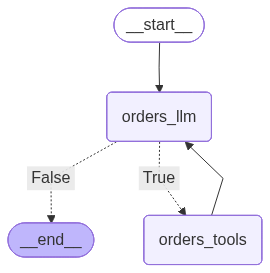

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage, SystemMessage, ToolMessage
from IPython.display import Image

class OrdersAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

class OrdersAgent:
    def __init__(self, model, tools, system_prompt, debug=False):
        self.system_prompt = system_prompt
        self.debug = debug

        agent_graph = StateGraph(OrdersAgentState)
        agent_graph.add_node("orders_llm", self.call_llm)
        agent_graph.add_node("orders_tools", self.call_tools)
        agent_graph.add_conditional_edges(
            "orders_llm",
            self.is_tool_call,
            {True: "orders_tools", False: END}
        )
        agent_graph.add_edge("orders_tools", "orders_llm")
        agent_graph.set_entry_point("orders_llm")

        self.memory = MemorySaver()
        self.agent_graph = agent_graph.compile(checkpointer=self.memory)

        self.tools = {tool.name: tool for tool in tools}
        if self.debug:
            print("\nTools loaded:", self.tools)

        self.model = model.bind_tools(tools)

    def call_llm(self, state: OrdersAgentState):
        messages = state["messages"]
        if self.system_prompt:
            messages = [SystemMessage(content=self.system_prompt)] + messages

        result = self.model.invoke(messages)
        if self.debug:
            print(f"\nLLM Returned: {result}")
        return {"messages": [result]}

    def is_tool_call(self, state: OrdersAgentState):
        last_message = state["messages"][-1]
        tool_calls = getattr(last_message, "tool_calls", None) or []
        return len(tool_calls) > 0

    def call_tools(self, state: OrdersAgentState):
        tool_calls = state["messages"][-1].tool_calls
        results = []

        for tool_call in tool_calls:
            if tool_call["name"] not in self.tools:
                result = "Invalid tool found. Please retry."
            else:
                result = self.tools[tool_call["name"]].invoke(tool_call["args"])

            results.append(
                ToolMessage(
                    tool_call_id=tool_call["id"],
                    name=tool_call["name"],
                    content=str(result)
                )
            )

        if self.debug:
            print(f"\nTools returned: {results}")

        return {"messages": results}

system_prompt = """
You are a professional chatbot that manages orders for laptops sold by our company.
The tools allow for retrieving order details as well as updating order quantity.
Do NOT reveal information about other orders than the one requested.
You will handle small talk and greetings by producing professional responses.
"""

orders_agent = OrdersAgent(
    model,
    [get_order_details, update_quantity],
    system_prompt,
    debug=False
)

Image(orders_agent.agent_graph.get_graph().draw_mermaid_png())
